# 03 — Model bakeoff: this project's lightweight detector vs. YOLO11n

This notebook compares this project's own `GridDetector` against a fine-tuned YOLO11n on
`drone`/`dismount`/`launch_flash` (the synthetic corridor scene) — the harder of the two
comparisons discussed in `docs/METHODOLOGY_AND_LIMITATIONS.md#model-comparison-lightweight-vs-production`,
since COCO has no classes matching this scenario's taxonomy, so a fair comparison requires
fine-tuning YOLO first rather than using it zero-shot.

The other comparison that document discusses — `vehicle_of_interest` on real UAVDT frames,
where stock COCO-pretrained YOLO already knows `car`/`truck`/`bus` and wins for free — isn't
re-run here to keep this notebook's runtime reasonable; it uses the same
`detectors.yolo_adapter.YOLOAdapter` / `COCO_TO_VEHICLE_SUBTYPE` machinery demonstrated in
`02_real_data_validation.ipynb`.

Requires `ultralytics` (`pip install -e ".[yolo]"`) and a `yolo11n.pt` weights file in the
project root.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from infrastructure_overwatch.synthetic import GRID, IMG_SIZE, N_SYNTHETIC_CLASSES, SYNTHETIC_CLASS_NAMES, SyntheticCorridorDataset, random_threats, render_day, render_night
from infrastructure_overwatch.detectors.grid_cnn import GridDetector, GridCNNAdapter, evaluate_grid_detector, train_grid_detector
from infrastructure_overwatch.detectors.yolo_adapter import YOLOAdapter
from infrastructure_overwatch.geometry import iou_xyxy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 6b. Fine-tune our own detector, and a fine-tuned YOLO11n, on the synthetic classes

In [3]:
day_train_ds = SyntheticCorridorDataset(800, domain="day", seed=1)
night_val_ds = SyntheticCorridorDataset(200, domain="night", seed=3)
day_train_loader = DataLoader(day_train_ds, batch_size=32, shuffle=True)

our_model = GridDetector(n_classes=N_SYNTHETIC_CLASSES, grid_h=GRID, grid_w=GRID)
train_grid_detector(our_model, day_train_loader, epochs=20, device=device, quiet=True)

night_small_train_ds = SyntheticCorridorDataset(100, domain="night", seed=99)
night_small_loader = DataLoader(night_small_train_ds, batch_size=16, shuffle=True)
train_grid_detector(our_model, night_small_loader, epochs=15, lr=2e-4, device=device, quiet=True)

our_adapter = GridCNNAdapter(our_model, class_names=SYNTHETIC_CLASS_NAMES, img_w=IMG_SIZE, img_h=IMG_SIZE, thresh=0.4, device=device)
our_score = evaluate_grid_detector(our_model, night_val_ds, IMG_SIZE, IMG_SIZE, device=device)
print(f"Our model, Night val -> F1 {our_score.f1:.2f}")

Our model, Night val -> F1 0.37


In [4]:
import shutil
from pathlib import Path
from PIL import Image

YOLO_DATA_DIR = Path("../yolo_threat_data")
if YOLO_DATA_DIR.exists():
    shutil.rmtree(YOLO_DATA_DIR)
for split in ["train", "val"]:
    (YOLO_DATA_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATA_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def write_yolo_split(split, n, domain, seed):
    for i in range(n):
        rng = np.random.default_rng(seed * 100_000 + i)
        threats = random_threats(rng)
        img, boxes = (render_day(threats, rng) if domain == "day" else render_night(threats, rng))
        img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        Image.fromarray(img_u8).save(YOLO_DATA_DIR / "images" / split / f"{domain}_{i:04d}.jpg", quality=90)
        lines = []
        for (x0, y0, x1, y1), cls in boxes:
            cx, cy = (x0 + x1) / 2 / IMG_SIZE, (y0 + y1) / 2 / IMG_SIZE
            w, h = (x1 - x0) / IMG_SIZE, (y1 - y0) / IMG_SIZE
            lines.append(f"{cls} {cx:.4f} {cy:.4f} {w:.4f} {h:.4f}")
        (YOLO_DATA_DIR / "labels" / split / f"{domain}_{i:04d}.txt").write_text("\n".join(lines))


write_yolo_split("train", 400, "day", seed=1001)
write_yolo_split("val", 100, "night", seed=1002)
data_yaml = YOLO_DATA_DIR / "data.yaml"
data_yaml.write_text(
    f"path: {YOLO_DATA_DIR.resolve()}\ntrain: images/train\nval: images/val\nnames: {list(SYNTHETIC_CLASS_NAMES)}\n"
)
print(f"Wrote synthetic YOLO-format dataset to {YOLO_DATA_DIR.resolve()}")

Wrote synthetic YOLO-format dataset to C:\dev\infrastructure-overwatch\yolo_threat_data


In [5]:
import contextlib, io as _io

from ultralytics import YOLO

yolo_threat_model = YOLO("../yolo11n.pt")
t0 = time.time()
with contextlib.redirect_stdout(_io.StringIO()):
    yolo_threat_model.train(
        data=str(data_yaml.resolve()), epochs=15, imgsz=96, batch=16,
        device=0 if torch.cuda.is_available() else "cpu",
        verbose=False, plots=False, val=True,
        project="../yolo_threat_runs", name="finetune", exist_ok=True,
    )
print(f"YOLO fine-tune done in {time.time()-t0:.1f}s")
yolo_threat_model.save("../yolo_threat_finetuned.pt")
yolo_adapter = YOLOAdapter(model_path="../yolo_threat_finetuned.pt", conf=0.15)

Ultralytics 8.4.150  Python-3.12.14 torch-2.14.0+cpu CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\dev\infrastructure-overwatch\yolo_threat_data\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=96, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

Overriding model.yaml nc=80 with nc=3



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

Ultralytics 8.4.150  Python-3.12.14 torch-2.14.0+cpu CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)


YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs


                   all        100        205       0.63       0.29      0.287      0.157


Speed: 0.0ms preprocess, 2.4ms inference, 0.0ms loss, 0.7ms postprocess per image


YOLO fine-tune done in 91.9s


  ours  -> precision 0.69  recall 0.29  F1 0.41
  yolo  -> precision 0.06  recall 0.07  F1 0.06


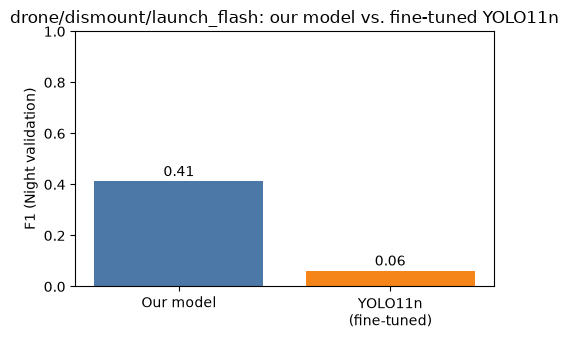

In [6]:
def compare_on_val(dataset, n=100):
    ours_tp = ours_fp = ours_fn = 0
    yolo_tp = yolo_fp = yolo_fn = 0
    n = min(n, len(dataset))
    for i in range(n):
        img_t, label = dataset[i]
        gray_img = np.repeat((img_t[0] * 255).astype(np.uint8)[:, :, None], 3, axis=2)

        from infrastructure_overwatch.grid_codec import decode_grid_predictions
        gt_boxes = [(b[0], b[1], b[2], b[3]) for b in decode_grid_predictions(label, IMG_SIZE, IMG_SIZE, GRID, GRID, thresh=0.5, nms_iou=1.1)]

        ours_preds = our_adapter.detect(img_t, f"F{i}")
        yolo_preds = yolo_adapter.detect(gray_img, f"F{i}")

        for preds, which in [(ours_preds, "ours"), (yolo_preds, "yolo")]:
            matched, tp, fp = set(), 0, 0
            for p in preds:
                best_iou, best_j = 0.0, -1
                for j, g in enumerate(gt_boxes):
                    if j not in matched:
                        v = iou_xyxy(p.xyxy, g)
                        if v > best_iou:
                            best_iou, best_j = v, j
                if best_iou >= 0.3:
                    tp += 1
                    matched.add(best_j)
                else:
                    fp += 1
            fn = len(gt_boxes) - len(matched)
            if which == "ours":
                ours_tp += tp; ours_fp += fp; ours_fn += fn
            else:
                yolo_tp += tp; yolo_fp += fp; yolo_fn += fn

    def f1(tp, fp, fn):
        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        return p, r, (2 * p * r / (p + r) if (p + r) else 0.0)

    return {"ours": f1(ours_tp, ours_fp, ours_fn), "yolo": f1(yolo_tp, yolo_fp, yolo_fn)}


threat_compare = compare_on_val(night_val_ds, n=100)
for name, (p, r, f) in threat_compare.items():
    print(f"  {name:5s} -> precision {p:.2f}  recall {r:.2f}  F1 {f:.2f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
names = ["Our model", "YOLO11n\n(fine-tuned)"]
f1s = [threat_compare["ours"][2], threat_compare["yolo"][2]]
bars = ax.bar(names, f1s, color=["#4C78A8", "#F58518"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 (Night validation)")
ax.set_title("drone/dismount/launch_flash: our model vs. fine-tuned YOLO11n")
for b, v in zip(bars, f1s, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Takeaway

Whether YOLO11n or this project's own small model wins depends on the class, not on "our
model" vs. "YOLO" in the abstract — see `docs/METHODOLOGY_AND_LIMITATIONS.md#model-comparison-lightweight-vs-production`
for the full reasoning, including the vehicle-track comparison where YOLO wins for free.